In [ ]:
#   1) Remova 25 amostras de cada espécie (setosa, versicolor, virginica)
#   e crie uma estratégia para criar estes dados artificialmentensimulando
#   a operação de dados faltantes.

#   2) Insira dados baseado na média de cada espécie para simular a operação de
#   dados faltantes.

#   3) Altere o dataset para simular uma situação de overfitting. (O modelo
#   possui muitos exemplos de uma espécie apenas)

#   4) Altere o dataset para simular uma situação de underfitting.
#   (O modelo possui poucos exemplos de cada espécie)

In [10]:
from sklearn.datasets import load_iris
from sklearn import tree

from sklearn.metrics import accuracy_score
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

iris = load_iris()
x = iris.data
y = iris.target


x_setosa=x[:50]
x_versicolor=x[50:100]
x_virginica= x[100:150]

#[linha], vou randomizar os valores inteiros
#Ex:
#Setosa-linha vai de 0 até 49
#Setosa-coluna vai de 0 até 3
# Eu vou retirar 25 amostras aleatórias, depois vou tratar dos dados faltantes

# Estratégia: Eu vou pegar as 25 amostras que restaram, vou supor que não tive
# contato prévio com as amostras removidas, vou analisar apenas as que ficaram
# e pegar o maior valor e o menor valor de cada coluna (ex: sepal_length)
# assim vou gerando números usando esse intervalo para substituírem os números
# removidos, para que os números gerados já tenham familiaridade com os valores
# da amostra de cada coluna.


def especie_amostra(x_specie):
  print("------------------------------------------------------------------")
  random_indices = random.sample(range(0, 50), 25)

  print("Removendo 25 amostras")
  for i in range(25):
    number = random_indices[i]
    x_specie[number][0] = np.nan
    x_specie[number][1] = np.nan
    x_specie[number][2] = np.nan
    x_specie[number][3] = np.nan


  # Contando os valores removidos
  count = 0
  for i in range(50):
    if (math.isnan(x_specie[i][0]) == True):
      count = count + 1
  print("Amostras removidas: ",count)
  print("------------------------------------------------------------------")

  print(x_specie) #Aqui aparece com as 25 amostras removidas
  def preencher_amostra_colunas(coluna):
    number = []
    for i in range(50):
      if (math.isnan(x_specie[i][coluna]) == False):
          number.append(x_specie[i][coluna])

    max_value = max(number)
    min_value = min(number)

    for i in range(50):
      valor_subst = round(random.uniform(min_value, max_value), 1)
      if (math.isnan(x_specie[i][coluna]) == True):
          x_specie[i][coluna]=valor_subst

  print("------------------------------------------------------------------")

  print("Preenchendo a espécie")
  print("------------------------------------------------------------------")
  for i in range(4):
    preencher_amostra_colunas(i)

  print(x_specie)
  print("")

print("Espécie: Setosa")
especie_amostra(x_setosa)

print("Espécie: Versicolor")
especie_amostra(x_versicolor)

print("Espécie: Virgínica")
especie_amostra(x_virginica)



x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


clf = tree.DecisionTreeClassifier()

clf.fit(x_train, y_train)

prev = clf.predict(x_test)


acc_treino_interval = round(clf.score(x_train, y_train) * 100, 1)
acc_teste_interval = round(accuracy_score(prev, y_test) * 100, 1)


print(prev)
print(y_test)
print("Acurácia: ",round(((accuracy_score(prev, y_test))*100),1))

Espécie: Setosa
------------------------------------------------------------------
Removendo 25 amostras
Amostras removidas:  25
------------------------------------------------------------------
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [nan nan nan nan]
 [4.6 3.1 1.5 0.2]
 [nan nan nan nan]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [nan nan nan nan]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [nan nan nan nan]
 [4.8 3.4 1.6 0.2]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [nan nan nan nan]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [nan nan nan nan]
 [nan nan nan nan]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [4.4 3.  1.3 0.2]
 [nan nan nan nan]
 [nan nan nan nan]
 [4.5 2.3 1.3 0.3]
 [nan 

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
x = iris.data
y = iris.target

x_setosa=x[:50]
x_versicolor=x[50:100]
x_virginica= x[100:150]

def especie_amostra_media(x_specie):
  random_indices = random.sample(range(0, 50), 25)

  print("Removendo 25 amostras")
  for i in range(25):
    number = random_indices[i]
    x_specie[number][0] = np.nan
    x_specie[number][1] = np.nan
    x_specie[number][2] = np.nan
    x_specie[number][3] = np.nan

    # Contando os valores removidos
    count = 0
    for i in range(50):
      if (math.isnan(x_specie[i][0]) == True):
        count = count + 1
  print("Amostras removidas: ",count)
  print("------------------------------------------------------------------")

  def preencher_amostra_colunas(coluna):
    media = 0
    calc = 0
    count_v = 0
    values = []
    for i in range(50):
      if (math.isnan(x_specie[i][coluna]) == False):
        count1= 0
        count_v = count_v + 1
        #print(x_setosa[i][0])
        calc = round(calc + x_specie[i][coluna],1)

    media = round(calc/count_v,1)
    print("Média: ", media)
    print("")

    for i in range(50):
        if (math.isnan(x_specie[i][coluna]) == True):
            x_specie[i][coluna]=media

  print("Preenchendo a espécie com a média")
  print("------------------------------------------------------------------")
  for i in range(4):
      preencher_amostra_colunas(i)

  print(x_specie)
  print("")
  print("")



print("Espécie: Setosa")
especie_amostra_media(x_setosa)

print("Espécie: Versicolor")
especie_amostra_media(x_versicolor)

print("Espécie: Virgínica")
especie_amostra_media(x_virginica)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


clf = tree.DecisionTreeClassifier()

clf.fit(x_train, y_train)

prev = clf.predict(x_test)

acc_treino_mean = round(clf.score(x_train, y_train) * 100, 1)
acc_teste_mean = round(accuracy_score(prev, y_test) * 100, 1)

print(prev)
print(y_test)
print("Acurácia: ",round(((accuracy_score(prev, y_test))*100),1))

Espécie: Setosa
Removendo 25 amostras
Amostras removidas:  25
------------------------------------------------------------------
Preenchendo a espécie com a média
------------------------------------------------------------------
Média:  5.0

Média:  3.4

Média:  1.5

Média:  0.2

[[5.  3.4 1.5 0.2]
 [4.9 3.  1.4 0.2]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.4 3.9 1.7 0.4]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [4.8 3.  1.4 0.1]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.1 3.8 1.5 0.3]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [4.8 3.4 1.9 0.2]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.2 3.5 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [4.7 3.2 1.6 0.2]
 [5.  3.4 1.5 0.2]
 [5.  3.4 1.5 0.2]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [5.  3.4 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.  3.4 1.5 0.2]
 [4.9 3.6 1.4 0

In [8]:
#Simulando Overfitting: vou reduzir o número de amostras REAIS das outras
# espécies para privilegiar a espécie Setosa, e analisar o impacto na
# capacidade preditiva (Acurácia)

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import random

iris = load_iris()
x = iris.data
y = iris.target
y_names = iris.target_names

x_setosa = x[:50]
x_versicolor = x[50:100]
x_virginica = x[100:150]

def reduzir_amostras(x_specie, quantidade_manter):
  indices = random.sample(range(0, 50), quantidade_manter)
  return x_specie[indices]

print("Amostra: Versicolor")
x_versicolor_of = reduzir_amostras(x_versicolor, 10)
print(f"Amostras mantidas: {len(x_versicolor_of)}")

print("Amostra: Virgínica")
x_virginica_of = reduzir_amostras(x_virginica, 10)
print(f"Amostras mantidas: {len(x_virginica_of)}")

x_overfit = np.vstack([x_setosa, x_versicolor_of, x_virginica_of])
y_overfit = np.array([0]*50 + [1]*10 + [2]*10)

x_train, x_test, y_train, y_test = train_test_split(
    x_overfit, y_overfit, test_size=0.2, random_state=42, stratify=y_overfit
)

clf = tree.DecisionTreeClassifier()
clf.fit(x_train, y_train)

prev = clf.predict(x_test)

acc_treino_of = round(clf.score(x_train, y_train) * 100, 1)
acc_teste_of = round(accuracy_score(prev, y_test) * 100, 1)

print(prev)
print(y_test)
print("Acurácia: ", round((accuracy_score(prev, y_test) * 100), 1))

Amostra: Versicolor
Amostras mantidas: 10
Amostra: Virgínica
Amostras mantidas: 10
[0 0 1 0 0 2 0 0 2 0 0 0 2 0]
[0 0 1 0 0 2 0 0 1 0 0 0 2 0]
Acurácia:  92.9


In [12]:
#Simulando Underfitting: vou reduzir o número de amostras de todas as amostras
# vou analisar o impacto na capacidade preditiva (Acurácia) com 8 amostras
#também reduzi a profundidade da árvore

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import numpy as np
import random

iris = load_iris()
x = iris.data
y = iris.target
y_names = iris.target_names

x_setosa = x[:50]
x_versicolor = x[50:100]
x_virginica = x[100:150]

def reduzir_amostras(x_specie, quantidade_manter):
  indices = random.sample(range(0, 50), quantidade_manter)
  return x_specie[indices]

print("Amostra: Versicolor")
x_versicolor_uf = reduzir_amostras(x_versicolor, 8)
print(f"Amostras mantidas: {len(x_versicolor_uf)}")

print("Amostra: Setosa")
x_setosa_uf = reduzir_amostras(x_setosa, 8)
print(f"Amostras mantidas: {len(x_setosa_uf)}")

print("Amostra: Virgínica")
x_virginica_uf = reduzir_amostras(x_virginica, 8)
print(f"Amostras mantidas: {len(x_virginica_uf)}")

x_underfit = np.vstack([x_setosa_uf, x_versicolor_uf, x_virginica_uf])
y_underfit = np.array([0]*8 + [1]*8 + [2]*8)

x_train, x_test, y_train, y_test = train_test_split(
    x_underfit, y_underfit, test_size=0.2, random_state=42, stratify=y_underfit
)

clf = tree.DecisionTreeClassifier(max_depth=1, random_state=42)
clf.fit(x_train, y_train)

prev = clf.predict(x_test)

acc_treino_uf = round(clf.score(x_train, y_train) * 100, 1)
acc_teste_uf = round(accuracy_score(prev, y_test) * 100, 1)

print(prev)
print(y_test)
print("Acurácia no TREINO: ", acc_treino_uf)
print("Acurácia no TESTE:  ", acc_teste_uf)
print("")

Amostra: Versicolor
Amostras mantidas: 8
Amostra: Setosa
Amostras mantidas: 8
Amostra: Virgínica
Amostras mantidas: 8
[1 1 1 0 1]
[2 1 1 0 2]
Acurácia no TREINO:  68.4
Acurácia no TESTE:   60.0



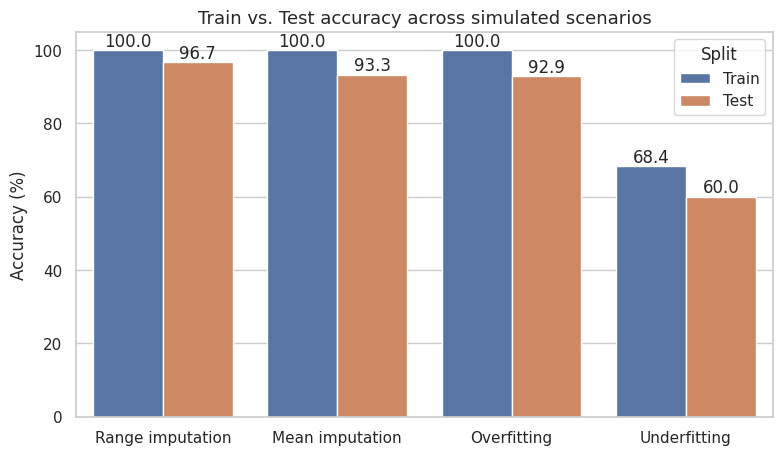

In [13]:
df_resultados = pd.DataFrame({
    'Scenario': ['Range imputation', 'Mean imputation', 'Overfitting', 'Underfitting'] * 2,
    'Accuracy': [acc_treino_interval, acc_treino_mean, acc_treino_of, acc_treino_uf,
                 acc_teste_interval,  acc_teste_mean,  acc_teste_of,  acc_teste_uf],
    'Split': ['Train'] * 4 + ['Test'] * 4
})

sns.set_theme(style='whitegrid')
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=df_resultados, x='Scenario', y='Accuracy', hue='Split',
                 palette=['#4C72B0', '#DD8452'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Train vs. Test accuracy across simulated scenarios', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.xlabel('')
plt.ylim(0, 105)
plt.show()